----

# Ice online shope project
---
Trabajas para la tienda online Ice que vende videojuegos por todo el mundo. Las reseñas de usuarios y expertos, los géneros, las plataformas (por ejemplo, Xbox o PlayStation) y los datos históricos sobre las ventas de juegos están disponibles en fuentes abiertas. Se tiene que identificar patrones que determinen si un juego tiene éxito o no. Esto  permitirá detectar proyectos prometedores y planificar campañas publicitarias.

Tenemos que hay datos que se remontan a 2016. Imagina que es diciembre de 2016 y se esta planeando una campaña para 2017.

Lo importante es adquirir experiencia de trabajo con datos. Realmente no importa si estamos pronosticando las ventas de 2017 en función de los datos de 2016 o las ventas de 2027 en función de los datos de 2026.

El dataset contiene una columna "rating" que almacena la clasificación ESRB de cada juego. El Entertainment Software Rating Board (la Junta de clasificación de software de entretenimiento) evalúa el contenido de un juego y asigna una clasificación de edad como Adolescente o Adulto.

## 1.Criterios de evaluación
---
Esto es lo que buscan los stake holders en el proyecto cuando evalúan tu proyecto:

- ¿Cómo describir los problemas identificados en los datos?
- ¿Cómo se preparar un dataset para el análisis?
- ¿Cómo crear gráficos de distribución y cómo los explicas?
- ¿Cómo calcular la desviación estándar y varianza?
- ¿Formular las hipótesis alternativas y nulas?
- ¿Qué métodos aplicas a la hora de probarlos?
- ¿Explicas los resultados de tus pruebas de hipótesis?
- ¿Sigues la estructura del proyecto y mantienes tu código ordenado y comprensible?
- ¿A qué conclusiones llegas?
- ¿Has dejado comentarios claros y relevantes en cada paso?
- Todo lo que necesitas para completar este proyecto se encuentra en las 
 hojas informativas y los resúmenes de los capítulos anteriores.

**Descripción**

## Estudia la información general

### 1.2 Cargar los datos

In [1]:
# importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# cargar el archivo de datos
juegos = pd.read_csv('/datasets/games.csv')

In [3]:
print(juegos.head())

                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22         1.00           NaN        NaN    NaN  


En este primer paso abrimos el archivo para empezar a estudiar la información.

### Paso 2 Preparar los datos

In [4]:
# Reemplazar los nombres de la columna
columns_names = juegos.columns
print(columns_names)

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='object')


In [5]:
# Reemplazar los nombres de la columna (cambiar a minusculas)
name_column =[]
for old_name in juegos.columns:
    name_lowered = old_name.lower()
    name_column.append(name_lowered)
juegos.columns=name_column
print(juegos.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


In [6]:
# revisar tabla
juegos.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [7]:
#revisar tipos de datos
juegos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


En este segundo paso empezamos reemplazando los nombres de las columnas y cambiarlos a minusculas como lo piden y mostramos la tabla y los tipos de datos que nos presentan.

In [8]:
#Convertir los datos en los tipos necesarios
#corregir la columna  year_of_release
juegos=juegos.dropna(subset={"year_of_release"})
juegos["year_of_release"]=juegos["year_of_release"].astype("int")
juegos.info(show_counts=True)


<class 'pandas.core.frame.DataFrame'>
Int64Index: 16446 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16446 non-null  object 
 2   year_of_release  16446 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16446 non-null  float64
 5   eu_sales         16446 non-null  float64
 6   jp_sales         16446 non-null  float64
 7   other_sales      16446 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       9839 non-null   object 
 10  rating           9768 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 1.5+ MB


In [9]:
juegos.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [10]:
juegos["critic_score"].unique()

array([76., nan, 82., 80., 89., 58., 87., 91., 61., 97., 95., 77., 88.,
       83., 94., 93., 85., 86., 98., 96., 90., 84., 73., 74., 78., 92.,
       71., 72., 68., 62., 49., 67., 81., 66., 56., 79., 70., 59., 64.,
       75., 60., 63., 69., 50., 25., 42., 44., 55., 48., 57., 29., 47.,
       65., 54., 20., 53., 37., 38., 33., 52., 30., 32., 43., 45., 51.,
       40., 46., 39., 34., 41., 36., 31., 27., 35., 26., 19., 28., 23.,
       24., 21., 17., 13.])

In [11]:
#corregir las columna critic_store
juegos["critic_score"].unique()
juegos["critic_score"]=juegos["critic_score"].astype(float)

In [12]:
juegos["critic_score"].isna().sum()/len(juegos["critic_score"])*100

51.45932141554177

In [13]:
# corregir la columna user_score
juegos["user_score"].unique()
juegos["user_score"]=juegos["user_score"].astype(object)

In [14]:
juegos["user_score"].isna().sum()/len(juegos["user_score"])*100

40.1739024686854

In [15]:
juegos["user_score"].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

In [16]:
juegos["user_score"]=juegos["user_score"].replace("tbd",np.nan)
juegos["user_score"]=juegos["user_score"].astype(float)

In [17]:
juegos["user_score"]

0        8.0
1        NaN
2        8.3
3        8.0
4        NaN
        ... 
16710    NaN
16711    NaN
16712    NaN
16713    NaN
16714    NaN
Name: user_score, Length: 16446, dtype: float64

In [18]:
juegos["rating"].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

In [19]:
# corregir la columna rating
juegos["rating"].unique()
juegos["rating"]=juegos["rating"].astype(object)

In [20]:
juegos["rating"].isna().sum()/len(juegos["rating"])*100

40.60561838744984

En el segundo inciso convertimos los datos en tipo necesarios es decir se modifificarón las columnas year_of_release, critic_score, user_score y rating, utilizando los métodos necesarios y en el caso de la columna user_score donde nos salio el Tbd lo consideramos como un string y utilizamos el metodo replace() para que no afectara su cambio.

# Describe las columnas en las que los tipos de datos han sido cambiados

En la columna year_of_release se tubo que modificar porque no podemos tener los años en fracción o float por lo que lo cambiamos a entero, en las columnas critic_score, user_score y rating se tubo que revisar si tenian NaN (no nulos), por lo que si tenian, pero como nuestros porcentajes salierón altos no era conveniente modificarlos.

# Si es necesario, elige la manera de tratar los valores ausentes

Por el anterior paso, No es necesario ya que sacando el porcentaje a cada una de la columnas de arriba mencionadas es elevado su porcentaje y no es combeniente,ya sea eliminarlos o limpiarlos.

In [21]:
#calcular las ventas totales para cada juego
juegos["ventas_totales"] = juegos["na_sales"] + juegos["eu_sales"] + juegos["jp_sales"] + juegos["other_sales"]

In [22]:
juegos

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,ventas_totales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN,0.01


En este último paso se calculo las ventas totales para cada juego y se creo una nueva columna donde colocamos sus valores. 

**Paso 3. Analiza los datos**

In [23]:
#mira cuantos juegos fueron lanzados en diferentes años.
juegos_agrupados=juegos.groupby("year_of_release")["name"].count().reset_index()
juegos_agrupados.head()

,year_of_release,name
0,1980,9
1,1981,46
2,1982,36
3,1983,17
4,1984,14


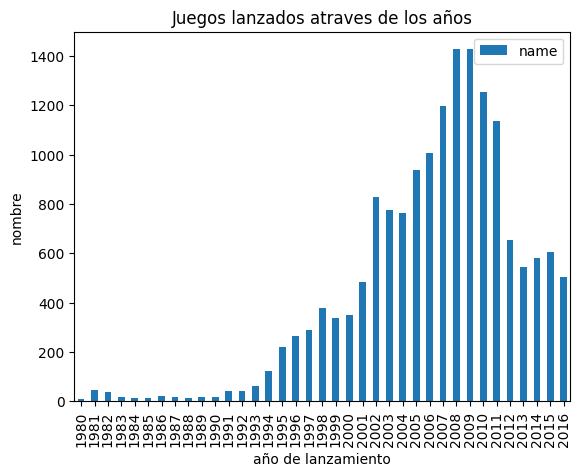

In [24]:
#hacer un grafico de barras
juegos_agrupados.plot(kind="bar",x="year_of_release",y="name",
           title="Juegos lanzados atraves de los años",
           xlabel="año de lanzamiento",
           ylabel="nombre"
           )
plt.show();

En este primer punto del analisis sacamos los juegos que se lanzarón en diferentes años y creamos un grafico de barras donde nos muestra si los datos son significativos en cada periodo, como podemos ver en la grafica apartir del año 1995 empieza un alza y en los años 2008 y 2009 llega a lo mas alto y apartir del 2012 hay una considerable baja.

In [25]:
#observa como varian las ventas de una plataforma a otra.
juegos_plataforma=juegos.groupby("platform")["ventas_totales"].sum().sort_values(ascending=False).reset_index().head(10)
juegos_plataforma["platform"]

0     PS2
1    X360
2     PS3
3     Wii
4      DS
5      PS
6     PS4
7     GBA
8     PSP
9     3DS
Name: platform, dtype: object

In [26]:
top10_platform=juegos[juegos["platform"].isin(juegos_plataforma["platform"])&(juegos["ventas_totales"]<15)]

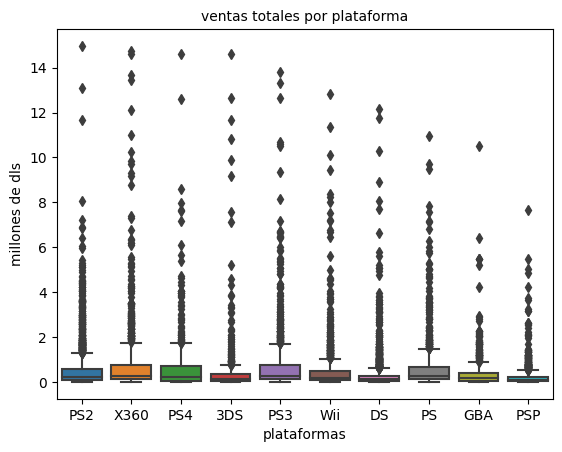

In [27]:
#diagrama de caja ver la distribucion
sns.boxplot(data=top10_platform,x="platform",y="ventas_totales")
plt.title("ventas totales por plataforma",size=10)
plt.xlabel("plataformas")
plt.ylabel("millones de dls")
plt.show();

En este paso se saco un top 10 de las plataformas con las ventas mas vendidas y las graficamos para que nos muestre los datos de cada año.

In [28]:
#busca las plataformas que solian ser populares pero ahora no tienen ventas
top10_populares=top10_platform.groupby(["platform","year_of_release"])["ventas_totales"].sum().reset_index()

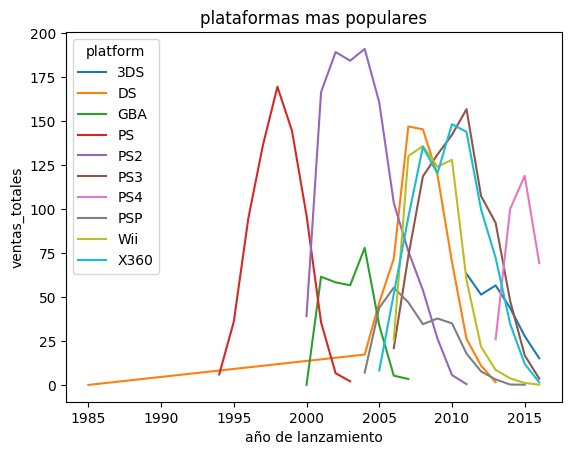

In [29]:
# graficar un diagrama de lineas 
sns.lineplot(data=top10_populares,x="year_of_release",y="ventas_totales",hue="platform")
plt.title("plataformas mas populares")
plt.xlabel("año de lanzamiento")
plt.ylabel("ventas_totales")
plt.show();

Continuando buscamos plataformas que solian ser populares pero que ahora ya no tienen ventas y graficamos un diagrama de lineas donde mostrara estas ventas como vemos en la grafica PS empieza a finales del 94 y termina por el 2004,PS2 empieza a finales del 99 y termina a principios del 2011,GBA empieza en el 2000 y termina en el 2007 y DS que empieza en el 85 y termina en el 2014 podemos decir que las antiguas tardan en desaparecer entre el 2004 y 2014 alrededor de 10 años y las nuevas como X360,Wii,PSP,PS4 aparecen a finales del 2004  y terminan a mediados del 2015.

In [30]:
#determina para que periodo debes tomar datos.
top10_platform["year_of_release"].unique()
top10 = top10_platform[top10_platform["year_of_release"]>=2000]

In [31]:
#trabaja solo con los datos que consideras relevantes
top10

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,ventas_totales
28,Gran Turismo 3: A-Spec,PS2,2001,Racing,6.85,5.09,1.87,1.16,95.0,8.4,E,14.97
29,Call of Duty: Modern Warfare 3,X360,2011,Shooter,9.04,4.24,0.13,1.32,88.0,3.4,M,14.73
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
32,Call of Duty: Black Ops,X360,2010,Shooter,9.70,3.68,0.11,1.13,87.0,6.3,M,14.62
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,NaN,14.60
...,...,...,...,...,...,...,...,...,...,...,...,...
16708,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN,0.01
16709,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,0.00,0.00,0.00,0.00,NaN,NaN,NaN,0.00
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN,0.01


Considerando este top 10 que se saco considero que apartir del 2000 nos podrian dar mejores datos para construir un modelo para el 2017.

In [32]:
#¿Que plataformas son lideres en ventas?
plat_norelevantes = ["PS","PS2","GBA","DS"]
rentables = top10_platform[~top10_platform["platform"].isin(plat_norelevantes)]

Aqui elegi a PS.PS2,GBA Y DS que ya no son relevantes podemos concluir que 3DS,PS3,PS4,Wii Y X360 son las lideres en ventas.

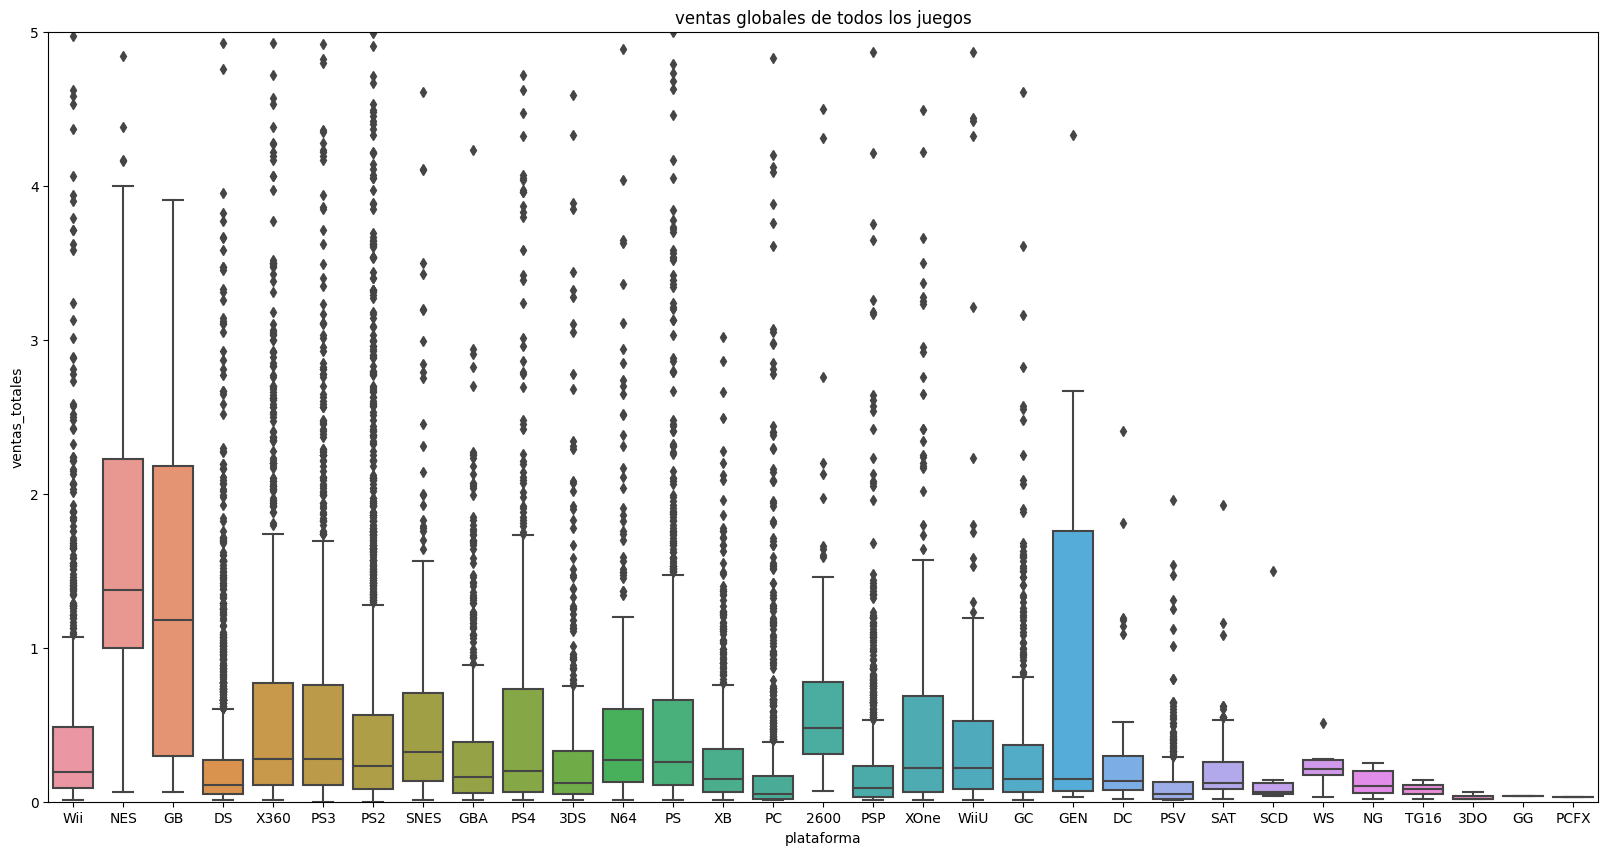

In [33]:
#crea un diagrama de caja para las ventas globales de todos los juegos
plt.figure(figsize=(20,10))
sns.boxplot(data=juegos,x="platform",y="ventas_totales")
plt.title("ventas globales de todos los juegos")
plt.xlabel("plataforma")
plt.ylabel("ventas_totales")
plt.ylim(0,5)
plt.show();

Aqui se muestra todos los juegos con sus ventas totales y si vemos en la grafica que tiene diferencias  tanto en sus ventas y en las ventas promedio.

In [34]:
#mira como las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular

ventas_plat = top10.groupby(["platform","name"])\
            [["ventas_totales",
              "user_score",
              "critic_score"
             ]].sum()
ps4 = ventas_plat.query(
    'platform == "PS4" & critic_score >0 & user_score >0').reset_index()

In [35]:
#crea la correlacion entre las reseñas y ventas
ps4["ventas_totales"].corr(ps4["user_score"])

-0.03362497596528893

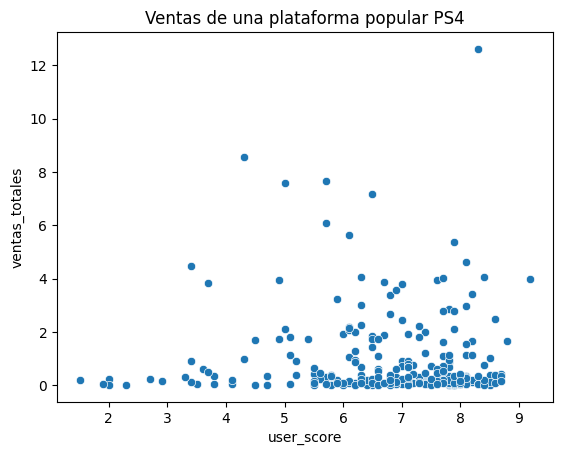

In [36]:
#crear un grafico de dispersión
sns.scatterplot(data=ps4,x="user_score",y="ventas_totales")
plt.title("Ventas de una plataforma popular PS4")
plt.xlabel("user_score")
plt.ylabel("ventas_totales")
plt.show();


En este paso se saco como las reseñas de los usuarios y profesionales afectan las ventas de una plataforma en este caso se eligio PS4, tambien se creo un grafico de dispersión y se calulo la correlación que hay pero por el resultado de -0-0336 que esta muy cercano al 0 concluimos que no tiene ninguna correlación.

In [37]:
#teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataforma
top10[top10["name"]=="Call of Duty: Modern Warfare 3"][["platform","ventas_totales"]]


,platform,ventas_totales
29,X360,14.73
37,PS3,13.33
2500,Wii,0.83


Aqui en este paso comparamos las ventas con otras plataformas y vemos que X360 es el que tiene mayor ventas.

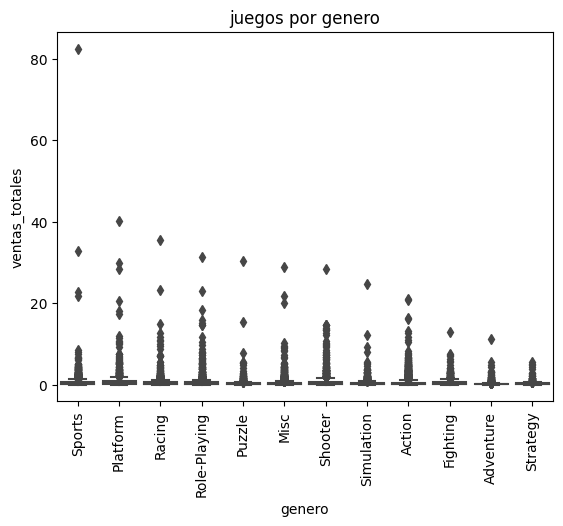

In [38]:
#echa un vistazo a la distribucion general de los juegos por genero
sns.boxplot(data=juegos,y="ventas_totales",x="genre")
plt.title("juegos por genero")
plt.xlabel("genero")
plt.ylabel("ventas_totales")
plt.xticks(rotation=90)
plt.show();

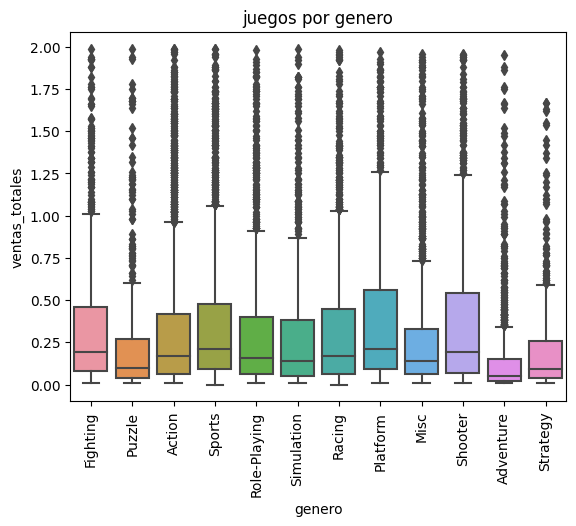

In [39]:
jue_genero = juegos[juegos["ventas_totales"]<2]
sns.boxplot(data=jue_genero,y="ventas_totales",x="genre")
plt.title("juegos por genero")
plt.xlabel("genero")
plt.ylabel("ventas_totales")
plt.xticks(rotation=90)
plt.show();

que en la grafica los generos fighting,sport,action,platform y shooter tienen las ventas mas altas y por consiguinte serian las mas rentables que las demas.

**Paso 4.Crea un perfil de usuario para cada región**

### Region NA

In [40]:
#las cinco plataformas principales
top10.groupby("platform")["na_sales"].sum().sort_values(ascending=False).head(5)

platform
X360    571.08
PS2     555.08
PS3     383.11
Wii     367.89
DS      330.21
Name: na_sales, dtype: float64

In [41]:
#los cinco generos principales
top10.groupby("genre")["na_sales"].mean().sort_values(ascending=False).head(5)

genre
Shooter     0.513175
Platform    0.350612
Sports      0.276054
Racing      0.265984
Fighting    0.259490
Name: na_sales, dtype: float64

In [42]:
#si las clasificaciones de ESRB afectan a la ventas en regiones individuales
top10.groupby("rating")["na_sales"].mean().sort_values(ascending=False).head(5)

rating
M       0.590343
E       0.294066
T       0.281612
EC      0.270000
E10+    0.267898
Name: na_sales, dtype: float64

###  REGION UE

In [43]:
top10.groupby("platform")["eu_sales"].sum().sort_values(ascending=False).head(5)

platform
PS2     326.74
PS3     318.12
X360    258.29
Wii     173.03
PS4     141.09
Name: eu_sales, dtype: float64

In [44]:
top10.groupby("genre")["eu_sales"].mean().sort_values(ascending=False).head(5)

genre
Shooter     0.311310
Racing      0.195770
Platform    0.194768
Action      0.162922
Sports      0.157463
Name: eu_sales, dtype: float64

In [45]:
top10.groupby("rating")["eu_sales"].mean().sort_values(ascending=False).head(5)

rating
M       0.381776
E       0.157579
T       0.151451
E10+    0.138183
EC      0.018000
Name: eu_sales, dtype: float64

###  REGION JP

In [46]:
top10.groupby("platform")["jp_sales"].sum().sort_values(ascending=False).head(5)


platform
DS     141.27
PS2    136.66
3DS    100.62
PS3     78.43
PSP     75.88
Name: jp_sales, dtype: float64

In [47]:
top10.groupby("genre")["jp_sales"].mean().sort_values(ascending=False).head(5)

genre
Role-Playing    0.199335
Fighting        0.074510
Strategy        0.071498
Platform        0.067291
Simulation      0.060695
Name: jp_sales, dtype: float64

In [48]:
top10.groupby("rating")["jp_sales"].mean().sort_values(ascending=False).head(5)

rating
T       0.059439
M       0.054579
E       0.039747
E10+    0.031851
EC      0.000000
Name: jp_sales, dtype: float64

Concluimos que para las cinco plataformas principales tanto para NA y UE no hay mucha diferencia en sus variaciones de cuotas pero con la s de JP si baja un poco,en los generos principales tambien NA Y UE no hay mucha diferencia en el promedio pero con JP si y en las clsificaciones si varian entre los tres el promedio y posiblemente afecten las ventas individuales regionales.

**Paso 5.Prueba las siguientes hipótesis**

In [49]:
#calificaciones promedio de los usuarios para las plataformas Xbox  y pc son iguales
xbox = juegos.dropna()[juegos["platform"]=="XOne"]["user_score"]
pc = juegos.dropna()[juegos["platform"]=="PC"]["user_score"]


/tmp/ipykernel_257/78708890.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  xbox = juegos.dropna()[juegos["platform"]=="XOne"]["user_score"]
/tmp/ipykernel_257/78708890.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pc = juegos.dropna()[juegos["platform"]=="PC"]["user_score"]


In [50]:
# h0 no hay ninguna diferencia
# ha si hay diferencia entre ellas
t,p = stats.ttest_ind(xbox,pc)
alpha=0.05
if p<alpha:
    print("Se rechaza la hipotesis nula")
else:
    print("No se rechaza la hipotesis nula")

Se rechaza la hipotesis nula


Empezamos primero filtrando y llamando la columna platform igualando a xbox y tambien la columna user_score, se hace igual para PC y por ultimo utilizamos el método dropna() porque como no habiamos limpiado y eliminado los NAN o nulos, tendriamos probemas al realizar el ejercicio y podemos concluir que las dos poblaciones son distintas y es por eso que se rechaza la hipotesis nula.

In [51]:
#calif. promedio de usuarios para los generos accion y deportes son diferentes
accion = juegos.dropna()[juegos["genre"]=="Action"]["user_score"]
deportes = juegos.dropna()[juegos["genre"]=="Sports"]["user_score"]


/tmp/ipykernel_257/3785865120.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  accion = juegos.dropna()[juegos["genre"]=="Action"]["user_score"]
/tmp/ipykernel_257/3785865120.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  deportes = juegos.dropna()[juegos["genre"]=="Sports"]["user_score"]


In [52]:
# h0 no hay ninguna diferencia
# ha si hay diferencia entre ellas
t,p = stats.ttest_ind(accion,deportes)
alpha=0.05
if p<alpha:
    print("Se rechaza  la hipotesis nula")
else:
    print("No se rechaza la hipotesis nula")
print("El valor p es:",p)

No se rechaza la hipotesis nula
El valor p es: 0.7959786214567501


Tambien aqui empezamos filtrando y llamando ahora a la columna genre pero aqui nos piden que sean diferentes y tambien utilizando la columna user_score tambien utilizamos el metodo dropna(),para eliminar los valores nulos y podemos concluir que las dos poblaciones tambien son diferentes  y aqui no se rechaza la hipotesis nula.

**Paso 6.Conclusión general**


1.- Empezamos cargando el archivo de datos para empezar a estudiar la información.

2.- En la preparación de datos iniciamos cambiando los nombres de las columnas a minusculas, despues convertimos las columnas al tipo de datos necesarios, describimos el porque han sido cambiadas, explicamos porque no fue necesario cambiar o limpiar los valores ausentes ya que en las tres columnas tienen un porcentaje alto y no nos conviene cambiarlos, por último en este punto de calculo las ventas totales de todas las regiones creando una nueva columna.

|indice|name|platform|year_of_release|genre|na_sales|eu_sales|jp_sales|other_sales|critic_score|user_score|rating|ventas_totales|
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | 
|28|Gran Turismo 3: A-Spec|	PS2|2001|Racing|6.85|5.09|1.87|1.16|95.0|8.4|E|14.97|
|29|Call of Duty: Modern Warfare 3|X360|2011|Shooter|9.04|4.24|0.13|1.32|88.0|3.4|M|14.73|
|31|Call of Duty: Black Ops 3|PS4|2015|Shooter|6.03|5.86|0.36|2.38|	NaN|NaN|NaN|14.63|
|32|Call of Duty: Black Ops|X360|2010|Shooter|9.70|3.68|0.11|1.13|87.0|6.3|	M|14.62|
|33|Pokemon X/Pokemon Y|3DS|2013|Role-Playing|5.28|4.19|4.35|0.78|NaN|NaN|NaN|14.60|

3.- En el analisis de datos empezamos creando un grafico de barras donde nos mostrara los juegos que fueron lanzados atraves de los años, se creo un top 10 de las mejores plataformas con mas ventas y rentables, tambien se grafico un diagrama de lineas donde identificamos tanto plataformas nuevas como obsoletas,donde tambien nos permite ver o determinar que a partir del 2000 nos permite construir un mejor modelo para el año 2017. 
Tambien elegimos las plataformas que son lideres en ventas como 3ds,ps3,ps4 entre otras de nuestro top10, creamos un diagrama de caja para las ventas globales de todos los juegos, se selecciono una plataforma popular como PS4 creando un grafico de dispersión y calculando su correlación con otras reseñas y ventas donde se concluyo que no tiene ninguna correlación por su valor muy chico,por otra parte comparamos las ventas de estos mismos juegos con otras plataformas donde x360 es la que tubo las mayores ventas.

|indice|platform|ventas_totales|
| --- | --- | --- |
|29|X360| 14.73|
|37|PS3|13.33|
|2500|Wii|0.83|

Por ultimo en este punto se hizo una distribución general de los juegos por genero.

4.- En este paso se realizo para cada region las variaciones en sus cuotas de mercado donde NA Y EU son muy parecidas las variaciones pero para JP si hay variación, con los generos tambien NA Y EU casi no hay diferencia en sus promedios pero con JP si varia mucho el su promedio y con las clasificaciones si hay variaciones entre las tres por lo cual si afectan sus ventas regionales individuales.

5.- En este ultimo paso probamos las hipotesis donde en el primer ejercicio nos piden dos poblaciones que sean igual la cual aqui nos esta pidiendo una hipotesis nula y en el segundo nos pide que sean diferentes por lo cual aqui nos pide una hipotesis alternativa, por lo que concluimos que para el primer ejercicio se rechaza la hipotesis nula y para el segundo ejercicio No se rechaza la hipotesis nula, pero para ambas las poblaciones son diferentes.
